In [1]:
import numpy as no
import pandas as pd
import matplotlib.pyplot as plt

plt.style.use("seaborn-v0_8-whitegrid")

prices = pd.read_csv(
    "./data/etf_prices_daily.csv",
    index_col=0,
    parse_dates=True
)

print("Daily price data:", prices.shape)
prices.head()

Daily price data: (2911, 6)


,GLD,IWM,QQQ,SPY,TLT,VNQ
Date,,,,,,
2015-01-02,114.080002,102.543129,94.561104,169.687866,92.287552,52.090744
2015-01-05,115.800003,101.172203,93.174072,166.623322,93.737244,52.375847
2015-01-06,117.120003,99.421906,91.924744,165.053925,95.426125,52.895351
2015-01-07,116.430000,100.646286,93.109749,167.110672,95.237640,53.706303
2015-01-08,115.940002,102.353447,94.891846,170.076050,93.976433,53.909031


In [2]:
monthly_prices = prices.resample("ME").last()

monthly_returns = monthly_prices.pct_change()

momentum_12_1=(
    monthly_prices.shift(1) / monthly_prices.shift(12))-1

print("Monthly prices data:", monthly_prices.shape)
momentum_12_1.tail()

Monthly prices data: (139, 6)


,GLD,IWM,QQQ,SPY,TLT,VNQ
Date,,,,,,
2026-03-31,0.678871,0.322161,0.299712,0.236998,0.039092,0.087289
2026-04-30,0.416499,0.286424,0.219791,0.186200,0.008863,0.044124
2026-05-31,0.395455,0.370096,0.292543,0.233306,0.033577,0.121372
2026-06-30,0.368369,0.356645,0.343361,0.234760,0.012126,0.106420
2026-07-31,0.215936,0.383703,0.309617,0.194539,0.035731,0.123677


In [8]:
top_n = 3

weights = pd.DataFrame(
    data =0.0,
    index= momentum_12_1.index,
    columns=momentum_12_1.columns
)

for date in momentum_12_1.index:
    signal = momentum_12_1.loc[date].dropna()

    if len(signal)>= top_n:
        selected_etfs= signal.nlargest(top_n).index
        weights.loc[date, selected_etfs]= 1/ top_n

weights.tail()

,GLD,IWM,QQQ,SPY,TLT,VNQ
Date,,,,,,
2026-03-31,0.333333,0.333333,0.333333,0.0,0.0,0.0
2026-04-30,0.333333,0.333333,0.333333,0.0,0.0,0.0
2026-05-31,0.333333,0.333333,0.333333,0.0,0.0,0.0
2026-06-30,0.333333,0.333333,0.333333,0.0,0.0,0.0
2026-07-31,0.333333,0.333333,0.333333,0.0,0.0,0.0


In [9]:
weight_sum =weights.sum(axis=1)

print(weight_sum.tail(15))

print("\nMonths where portfolio weights do not sum to 1:")
print(weight_sum[weight_sum !=1].tail(15))

Date
2025-05-31    1.0
2025-06-30    1.0
2025-07-31    1.0
2025-08-31    1.0
2025-09-30    1.0
2025-10-31    1.0
2025-11-30    1.0
2025-12-31    1.0
2026-01-31    1.0
2026-02-28    1.0
2026-03-31    1.0
2026-04-30    1.0
2026-05-31    1.0
2026-06-30    1.0
2026-07-31    1.0
Freq: ME, dtype: float64

Months where portfolio weights do not sum to 1:
Date
2015-01-31    0.0
2015-02-28    0.0
2015-03-31    0.0
2015-04-30    0.0
2015-05-31    0.0
2015-06-30    0.0
2015-07-31    0.0
2015-08-31    0.0
2015-09-30    0.0
2015-10-31    0.0
2015-11-30    0.0
2015-12-31    0.0
Freq: ME, dtype: float64


In [11]:
strategy_gross_returns =(
    weights.shift(1)* monthly_returns
).sum(axis=1)

strategy_gross_returns = strategy_gross_returns.dropna()
strategy_gross_returns.name = "Momentum Strategy (Gross)"

strategy_gross_returns.head(10)

Date
2015-01-31    0.0
2015-02-28    0.0
2015-03-31    0.0
2015-04-30    0.0
2015-05-31    0.0
2015-06-30    0.0
2015-07-31    0.0
2015-08-31    0.0
2015-09-30    0.0
2015-10-31    0.0
Freq: ME, Name: Momentum Strategy (Gross), dtype: float64

In [12]:
benchmark_returns = monthly_returns.mean(axis=1)
benchmark_returns.name = "Equal-Weight Benchmark"

comparison_returns = pd.concat(
    [strategy_gross_returns, benchmark_returns],
    axis = 1
).dropna()
comparison_returns.head()

,Momentum Strategy (Gross),Equal-Weight Benchmark
Date,,
2015-02-28,0.0,0.005116
2015-03-31,0.0,-0.002479
2015-04-30,0.0,-0.015165
2015-05-31,0.0,0.006085
2015-06-30,0.0,-0.023315


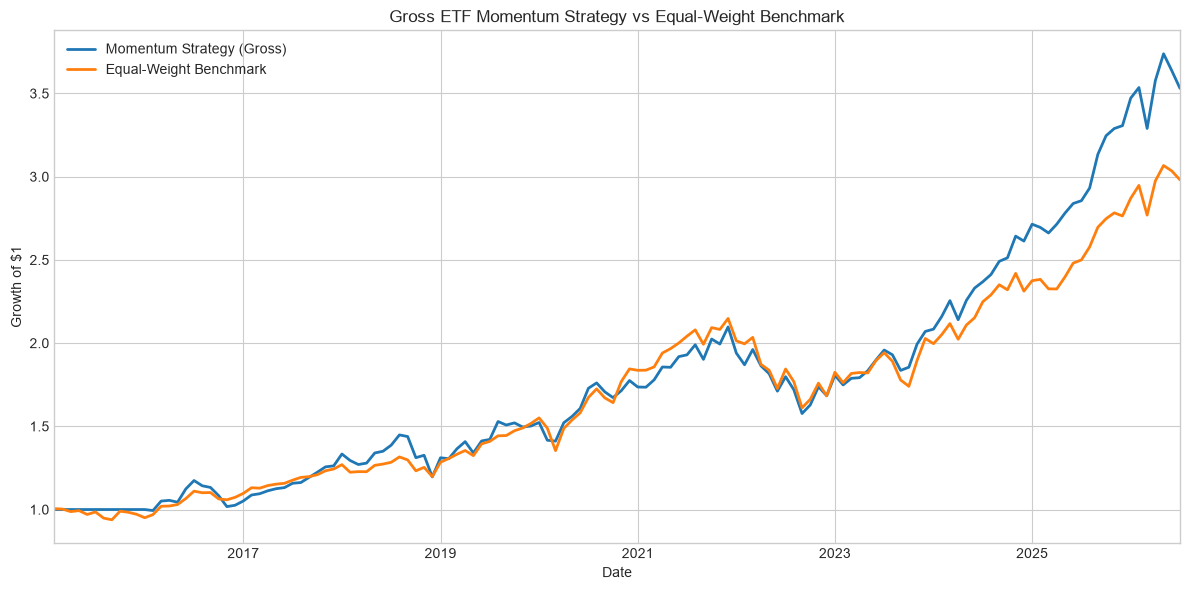

In [15]:
equity_curve = (1 + comparison_returns).cumprod()

equity_curve.plot(figsize=(12,6),linewidth=2)

plt.title("Gross ETF Momentum Strategy vs Equal-Weight Benchmark")
plt.xlabel("Date")
plt.ylabel("Growth of $1")
plt.grid(True)
plt.tight_layout()
plt.show()

In [16]:
weights.to_csv("./data/momentum_weights.csv")
comparison_returns.to_csv("./data/gross_strategy_and_benchmark_returns.csv")
print("Saved portfolio weights and gross returns for Part 4")

Saved portfolio weights and gross returns for Part 4
